In [72]:
# General purpose
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Signal processing
from scipy.io import loadmat
from scipy.ndimage import convolve1d
from scipy.signal import welch

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [73]:
# ==================================================
# Configuration (change these first)
# ==================================================
FS = 2000  # sampling frequency (Hz)
MOV_MEAN_LENGTH = 100

SUBJECT_IDS = range(1, 28)
SUBJECT_OF_INTEREST = 27

filepath_mat_list = [f"data/S{subject_id}_A1_E1.mat" for subject_id in SUBJECT_IDS]
print(f"Number of subjects: {len(filepath_mat_list)}")
print(f"Example file: {filepath_mat_list[0]}")

Number of subjects: 27
Example file: data/S1_A1_E1.mat


In [74]:
# (Optional) quick sanity check
print(filepath_mat_list[:3])
print(f"SUBJECT_OF_INTEREST = {SUBJECT_OF_INTEREST}")

['data/S1_A1_E1.mat', 'data/S2_A1_E1.mat', 'data/S3_A1_E1.mat']
SUBJECT_OF_INTEREST = 27


In [75]:
def _to_1d(mat_dict: dict, key: str, n_samples: int) -> np.ndarray:
    """Return a (n_samples,) float array for `key` if present, else zeros."""
    arr = mat_dict.get(key, np.zeros((n_samples,)))
    arr = np.asarray(arr).squeeze()
    if arr.ndim != 1:
        arr = arr.ravel()
    return arr


data_list = []
for subject_id, filepath in zip(SUBJECT_IDS, filepath_mat_list):
    mat = loadmat(filepath)
    mat = {key: mat[key] for key in mat.keys() if not key.startswith("__")}

    emg = np.asarray(mat["emg"])  # shape (n_samples, n_channels)
    n_samples, n_channels = emg.shape
    print(f"Subject {subject_id:2d}: EMG shape {emg.shape}")

    # Use the *corrected* labels for all downstream work.
    stimulus_clean = _to_1d(mat, "restimulus", n_samples)
    repetition_clean = _to_1d(mat, "rerepetition", n_samples)

    # Keep raw labels too (sometimes useful for debugging).
    stimulus_raw = _to_1d(mat, "stimulus", n_samples)
    repetition_raw = _to_1d(mat, "repetition", n_samples)

    emg_cols = {f"emg_ch{ch+1}": emg[:, ch] for ch in range(n_channels)}
    df = pd.DataFrame(emg_cols)
    df["stimulus"] = stimulus_clean
    df["repetition"] = repetition_clean
    df["stimulus_raw"] = stimulus_raw
    df["repetition_raw"] = repetition_raw
    df["subject_id"] = subject_id

    data_list.append(df)

all_data = pd.concat(data_list, ignore_index=True)
print(all_data.head())

Subject  1: EMG shape (101014, 10)
Subject  2: EMG shape (100686, 10)
Subject  3: EMG shape (100720, 10)
Subject  4: EMG shape (100835, 10)
Subject  5: EMG shape (100894, 10)
Subject  6: EMG shape (101083, 10)
Subject  7: EMG shape (100817, 10)
Subject  8: EMG shape (100854, 10)
Subject  9: EMG shape (100925, 10)
Subject 10: EMG shape (100778, 10)
Subject 11: EMG shape (100899, 10)
Subject 12: EMG shape (100920, 10)
Subject 13: EMG shape (100948, 10)
Subject 14: EMG shape (100785, 10)
Subject 15: EMG shape (101508, 10)
Subject 16: EMG shape (101191, 10)
Subject 17: EMG shape (101675, 10)
Subject 18: EMG shape (101323, 10)
Subject 19: EMG shape (101299, 10)
Subject 20: EMG shape (101565, 10)
Subject 21: EMG shape (101732, 10)
Subject 22: EMG shape (101884, 10)
Subject 23: EMG shape (101221, 10)
Subject 24: EMG shape (101698, 10)
Subject 25: EMG shape (101549, 10)
Subject 26: EMG shape (101642, 10)
Subject 27: EMG shape (100948, 10)
   emg_ch1  emg_ch2  emg_ch3  emg_ch4  emg_ch5  emg_ch6

## Data Inspection
Quick, beginner-friendly plots to verify labels and signal envelopes look reasonable.

Subject 27: emg=(100948, 10), stimuli=12, reps=10


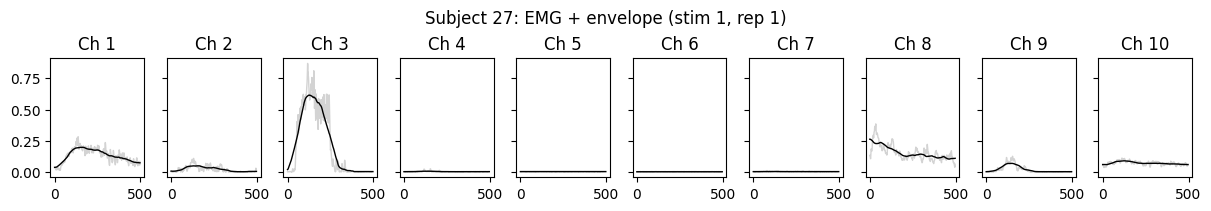

In [76]:
# Inspect a subset of subjects (set to SUBJECT_IDS to loop over all)
subjects_to_inspect = [SUBJECT_OF_INTEREST]

emg_columns = [c for c in all_data.columns if c.startswith("emg_ch")]
n_channels = len(emg_columns)

mov_mean_weights = np.ones(MOV_MEAN_LENGTH) / MOV_MEAN_LENGTH

for subject_id in subjects_to_inspect:
    subject_data = all_data[all_data["subject_id"] == subject_id]
    emg = subject_data[emg_columns].to_numpy()
    stimulus = subject_data["stimulus"].to_numpy()
    repetition = subject_data["repetition"].to_numpy()

    n_stimuli = np.unique(stimulus).size - 1  # exclude 0 (rest)
    n_repetitions = np.unique(repetition).size - 1  # exclude 0 (no repetition)

    print(f"Subject {subject_id}: emg={emg.shape}, stimuli={n_stimuli}, reps={n_repetitions}")

    # Build windowed data for one example (stimulus 1, repetition 1)
    stim_idx, rep_idx = 1, 1
    idx = (stimulus == stim_idx) & (repetition == rep_idx)
    emg_window = emg[idx, :]
    emg_envelope = convolve1d(emg_window, mov_mean_weights, axis=0)

    # Plot all channels on the same y-scale
    fig, ax = plt.subplots(1, n_channels, figsize=(12, 2), constrained_layout=True, sharex=True, sharey=True)
    ax = np.ravel(ax)

    for ch in range(n_channels):
        ax[ch].plot(emg_window[:, ch], color="lightgray", linewidth=1)
        ax[ch].plot(emg_envelope[:, ch], color="black", linewidth=1)
        ax[ch].set_title(f"Ch {ch+1}")

    plt.suptitle(f"Subject {subject_id}: EMG + envelope (stim {stim_idx}, rep {rep_idx})")
    plt.show()

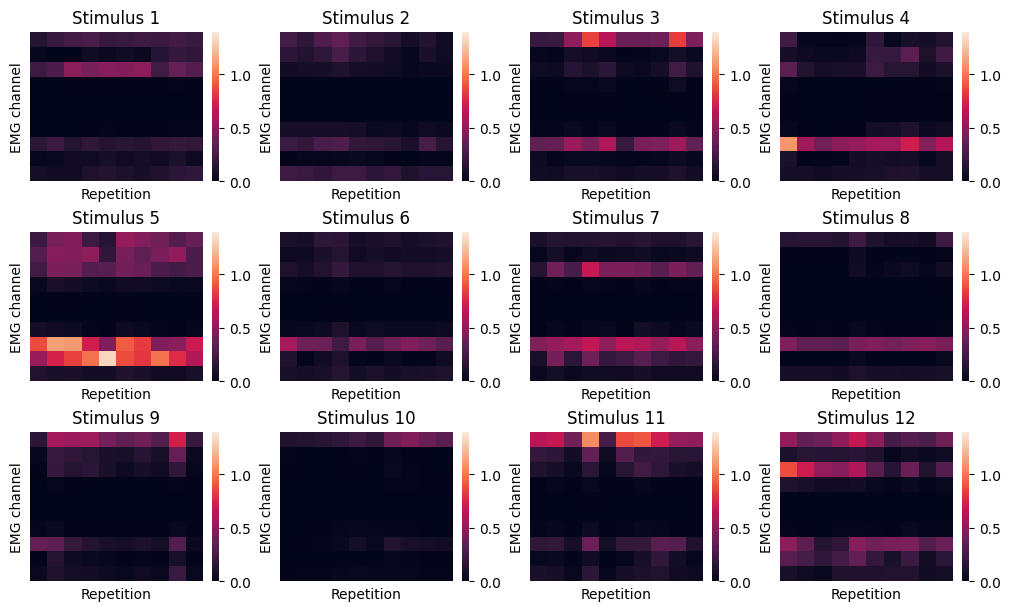

In [77]:
# Heatmaps of average envelope activations per stimulus/repetition (Subject of interest)
subject_data = all_data[all_data["subject_id"] == SUBJECT_OF_INTEREST]
emg = subject_data[emg_columns].to_numpy()
stimulus = subject_data["stimulus"].to_numpy()
repetition = subject_data["repetition"].to_numpy()

n_stimuli = np.unique(stimulus).size - 1
n_repetitions = np.unique(repetition).size - 1

# Precompute envelopes for each (stimulus, repetition)
emg_envelopes = [[None for _ in range(n_repetitions)] for _ in range(n_stimuli)]
for stim_idx in range(1, n_stimuli + 1):
    for rep_idx in range(1, n_repetitions + 1):
        idx = (stimulus == stim_idx) & (repetition == rep_idx)
        emg_envelopes[stim_idx - 1][rep_idx - 1] = convolve1d(emg[idx, :], mov_mean_weights, axis=0)

emg_average_activations = np.zeros((n_channels, n_stimuli, n_repetitions))
for stim_i in range(n_stimuli):
    for rep_i in range(n_repetitions):
        emg_average_activations[:, stim_i, rep_i] = np.mean(emg_envelopes[stim_i][rep_i], axis=0)

fig, ax = plt.subplots(3, 4, figsize=(10, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()
for stim_i in range(n_stimuli):
    sns.heatmap(
        np.squeeze(emg_average_activations[:, stim_i, :]),
        ax=ax[stim_i],
        vmin=0,
        vmax=1.4,
        xticklabels=False,
        yticklabels=False,
        cbar=True,
    )
    ax[stim_i].set_title(f"Stimulus {stim_i + 1}")
    ax[stim_i].set_xlabel("Repetition")
    ax[stim_i].set_ylabel("EMG channel")
plt.show()

In [78]:
def build_dataset_from_ninapro(
    emg: np.ndarray,
    stimulus: np.ndarray,
    repetition: np.ndarray,
    features=None,
    *,
    exclude_rest: bool = True,
    ) -> tuple[np.ndarray, np.ndarray]:
    """
    Build a trial-level dataset (one row per (stimulus, repetition)).
    - emg: (n_samples, n_channels)
    - stimulus/repetition: (n_samples,) integer labels (0 means rest / no repetition)
    - features: list of callables f(window)->(n_channels,)
    Returns: X (n_trials, n_features_total), y (n_trials,)
    """
    if features is None:
        features = []

    stimulus = np.asarray(stimulus).squeeze()
    repetition = np.asarray(repetition).squeeze()

    stim_values = np.unique(stimulus)
    rep_values = np.unique(repetition)

    if exclude_rest:
        stim_values = stim_values[stim_values != 0]
        rep_values = rep_values[rep_values != 0]

    n_stimuli = stim_values.size
    n_repetitions = rep_values.size
    n_trials = n_stimuli * n_repetitions

    n_channels = emg.shape[1]
    n_features_total = n_channels * len(features)

    X = np.zeros((n_trials, n_features_total), dtype=float)
    y = np.zeros(n_trials, dtype=float)

    trial_idx = 0
    for stim in stim_values:
        for rep in rep_values:
            mask = (stimulus == stim) & (repetition == rep)
            window = emg[mask, :]
            y[trial_idx] = stim

            for feat_idx, feat_fn in enumerate(features):
                start = feat_idx * n_channels
                X[trial_idx, start : start + n_channels] = feat_fn(window)

            trial_idx += 1

    return X, y

In [79]:
# ===============================
# Feature functions (per channel)
# ===============================

def mav(x: np.ndarray) -> np.ndarray:
    return np.mean(np.abs(x), axis=0)

def std(x: np.ndarray) -> np.ndarray:
    return np.std(x, axis=0)

def maxav(x: np.ndarray) -> np.ndarray:
    return np.max(np.abs(x), axis=0)

def rms(x: np.ndarray) -> np.ndarray:
    return np.sqrt(np.mean(x**2, axis=0))

def wl(x: np.ndarray) -> np.ndarray:
    return np.sum(np.abs(np.diff(x, axis=0)), axis=0)

def ssc(x: np.ndarray) -> np.ndarray:
    dx = np.diff(x, axis=0)
    return np.sum((dx[:-1, :] * dx[1:, :]) < 0, axis=0).astype(float)

def zc(x: np.ndarray, th: float = 0.01) -> np.ndarray:
    """Zero crossings with a simple threshold (same logic as before, but explicit)."""
    dx = x[:-1, :] * x[1:, :]
    crossings = ((dx < 0) & (np.abs(x[:-1, :]) > th)) | (np.abs(x[1:, :]) > th)
    return np.sum(crossings, axis=0).astype(float)

def wamp(x: np.ndarray, th: float = 0.02) -> np.ndarray:
    return np.sum(np.abs(np.diff(x, axis=0)) > th, axis=0).astype(float)

def mean_freq(x: np.ndarray, fs: int = FS) -> np.ndarray:
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Psum = np.sum(Pxx, axis=0) + 1e-12
    return np.sum(f[:, None] * Pxx, axis=0) / Psum

def median_freq(x: np.ndarray, fs: int = FS) -> np.ndarray:
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Pcum = np.cumsum(Pxx, axis=0)
    total = Pcum[-1, :] + 1e-12
    med = np.zeros(x.shape[1])
    for c in range(x.shape[1]):
        idx = np.searchsorted(Pcum[:, c], total[c] / 2.0)
        med[c] = f[min(idx, f.size - 1)]
    return med

all_features = {
    "mav": mav,
    "std": std,
    "maxav": maxav,
    "rms": rms,
    "wl": wl,
    "ssc": ssc,
    "zc": zc,
    "wamp": wamp,
    "mean_freq": mean_freq,
    "median_freq": median_freq,
}

In [80]:
# Pre-calculate features for all subjects (one row per trial)
print("Pre-calculating features for all subjects...")

feature_names = list(all_features.keys())
feature_fns = [all_features[name] for name in feature_names]

subjects = np.sort(all_data["subject_id"].unique())
subject_features: dict[int, dict[str, np.ndarray]] = {}

for subj in subjects:
    subj_df = all_data[all_data["subject_id"] == subj]
    emg_sub = subj_df[emg_columns].to_numpy()
    stimulus_sub = subj_df["stimulus"].to_numpy()
    repetition_sub = subj_df["repetition"].to_numpy()

    X_sub, y_sub = build_dataset_from_ninapro(
        emg=emg_sub, stimulus=stimulus_sub, repetition=repetition_sub, features=feature_fns
    )

    subject_features[int(subj)] = {"X": X_sub, "y": y_sub}
    print(f"Subject {int(subj):2d}: X {X_sub.shape}, y {y_sub.shape}")

print("\nFeature pre-calculation complete!")
print(f"Total subjects: {len(subject_features)}")
print(f"Example subject shape: {subject_features[int(subjects[0])]['X'].shape}")

Pre-calculating features for all subjects...
Subject  1: X (120, 100), y (120,)
Subject  2: X (120, 100), y (120,)
Subject  3: X (120, 100), y (120,)
Subject  4: X (120, 100), y (120,)
Subject  5: X (120, 100), y (120,)
Subject  6: X (120, 100), y (120,)
Subject  7: X (120, 100), y (120,)
Subject  8: X (120, 100), y (120,)
Subject  9: X (120, 100), y (120,)
Subject 10: X (120, 100), y (120,)
Subject 11: X (120, 100), y (120,)
Subject 12: X (120, 100), y (120,)
Subject 13: X (120, 100), y (120,)
Subject 14: X (120, 100), y (120,)
Subject 15: X (120, 100), y (120,)
Subject 16: X (120, 100), y (120,)
Subject 17: X (120, 100), y (120,)
Subject 18: X (120, 100), y (120,)
Subject 19: X (120, 100), y (120,)
Subject 20: X (120, 100), y (120,)
Subject 21: X (120, 100), y (120,)
Subject 22: X (120, 100), y (120,)
Subject 23: X (120, 100), y (120,)
Subject 24: X (120, 100), y (120,)
Subject 25: X (120, 100), y (120,)
Subject 26: X (120, 100), y (120,)
Subject 27: X (120, 100), y (120,)

Feature p

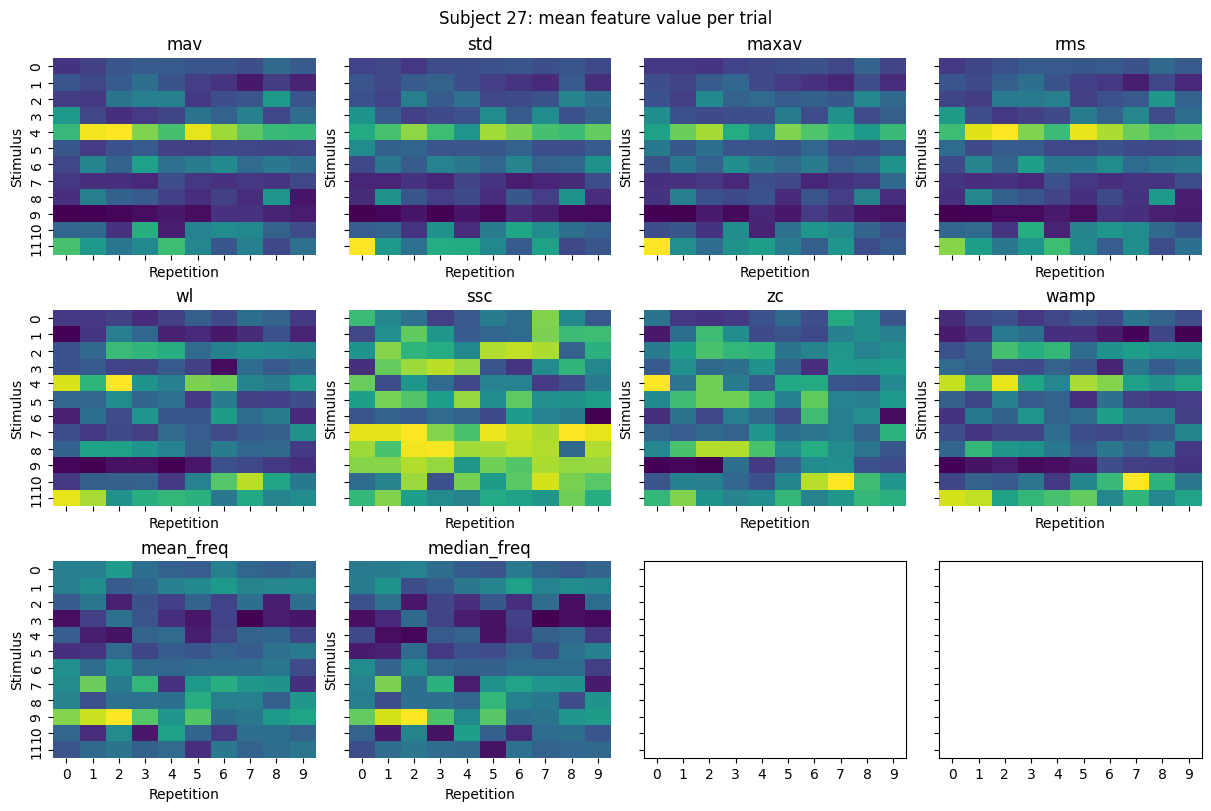

In [81]:
# Visualize feature values across trials for the subject of interest
subj_df = all_data[all_data["subject_id"] == SUBJECT_OF_INTEREST]
emg = subj_df[emg_columns].to_numpy()
stimulus = subj_df["stimulus"].to_numpy()
repetition = subj_df["repetition"].to_numpy()

n_stimuli = np.unique(stimulus).size - 1
n_repetitions = np.unique(repetition).size - 1

fig, ax = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for ax_idx, (feat_name, feat_fn) in enumerate(all_features.items()):
    feature_values = []
    for stim_idx in range(1, n_stimuli + 1):
        for rep_idx in range(1, n_repetitions + 1):
            mask = (stimulus == stim_idx) & (repetition == rep_idx)
            feature_value = feat_fn(emg[mask, :])
            feature_values.append(np.mean(feature_value))  # mean across channels
    sns.heatmap(
        np.array(feature_values).reshape(n_stimuli, n_repetitions),
        annot=False,
        fmt=".2f",
        ax=ax[ax_idx],
        cmap="viridis",
        cbar=False,
    )
    ax[ax_idx].set_title(feat_name)
    ax[ax_idx].set_xlabel("Repetition")
    ax[ax_idx].set_ylabel("Stimulus")

plt.suptitle(f"Subject {SUBJECT_OF_INTEREST}: mean feature value per trial")
plt.show()

TASK 2: Cross-Subject Feature Analysis

Feature matrix shape: (27, 100)
Subjects: 27, Features: 10, Channels: 10


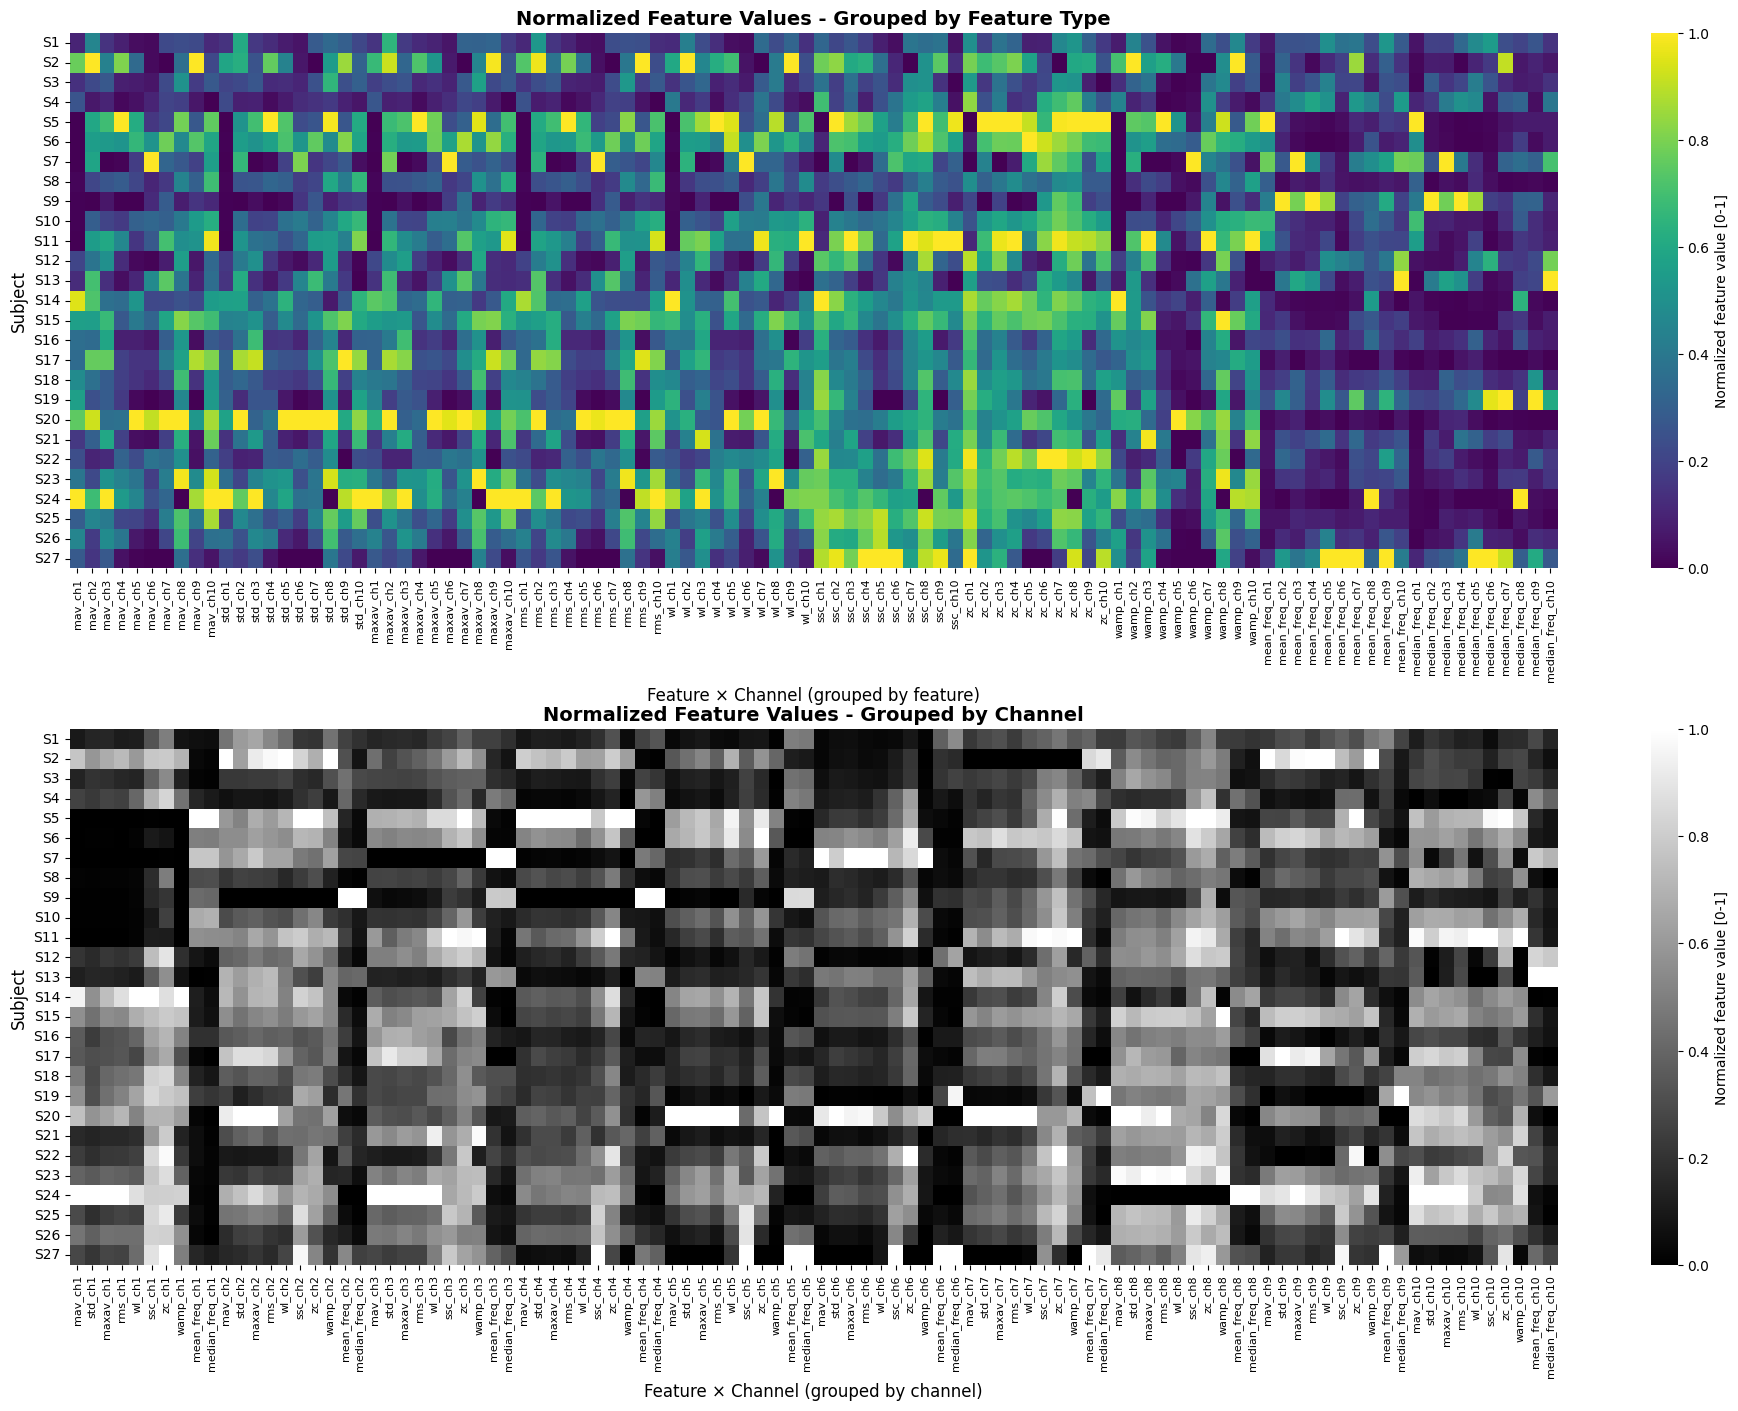

In [82]:
# Cross-Subject Feature Comparison (Task 2)
print("=" * 70)
print("TASK 2: Cross-Subject Feature Analysis")
print("=" * 70)

# Build per-(feature,channel) column labels, e.g. mav_ch1 ... median_freq_ch10
feature_labels = [f"{feat}_ch{ch}" for feat in feature_names for ch in range(1, n_channels + 1)]

n_subjects = len(subjects)
n_total_features = len(feature_labels)
subject_feature_matrix = np.zeros((n_subjects, n_total_features))

for subj_idx, subj in enumerate(subjects):
    X_sub = subject_features[int(subj)]["X"]
    subject_feature_matrix[subj_idx, :] = np.mean(X_sub, axis=0)

feature_df = pd.DataFrame(
    subject_feature_matrix,
    columns=feature_labels,
    index=[f"S{int(s)}" for s in subjects],
)

print(f"\nFeature matrix shape: {feature_df.shape}")
print(f"Subjects: {n_subjects}, Features: {len(feature_names)}, Channels: {n_channels}")

# Normalize each column to [0,1] for visualization
den = (feature_df.max() - feature_df.min()).replace(0, np.nan)
feature_df_normalized = (feature_df - feature_df.min()) / den
feature_df_normalized = feature_df_normalized.fillna(0.0)

fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.3)


In [ ]:
# === HEATMAP 1: Features grouped by type ===

sns.heatmap(
    feature_df_normalized,
    cmap="viridis",
    cbar_kws={"label": "Normalized feature value [0-1]"},
    xticklabels=True,
    yticklabels=True,
    )

plt.title("Normalized Feature Values - Grouped by Feature Type", fontsize=14, fontweight="bold")
plt.xlabel("Feature × Channel (grouped by feature)", fontsize=12)
plt.ylabel("Subject", fontsize=12)
plt.tick_params(axis="x", rotation=90, labelsize=8)
plt.tick_params(axis="y", labelsize=10)
plt.show()

In [ ]:
# === HEATMAP 2: Features grouped by channel ===
feature_labels_by_channel = [f"{feat}_ch{ch}" for ch in range(1, n_channels + 1) for feat in feature_names]
feature_df_by_channel = feature_df_normalized[feature_labels_by_channel]

sns.heatmap(
    feature_df_by_channel,
    cmap="gray",
    cbar_kws={"label": "Normalized feature value [0-1]"},
    xticklabels=True,
    yticklabels=True,
    )

plt.title("Normalized Feature Values - Grouped by Channel", fontsize=14, fontweight="bold")
plt.xlabel("Feature × Channel (grouped by channel)", fontsize=12)
plt.ylabel("Subject", fontsize=12)
plt.tick_params(axis="x", rotation=90, labelsize=8)
plt.tick_params(axis="y", labelsize=10)
plt.show()

/var/folders/5f/6pq8n0ws7c99q7szkxs11zrc0000gn/T/ipykernel_10866/2549922728.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


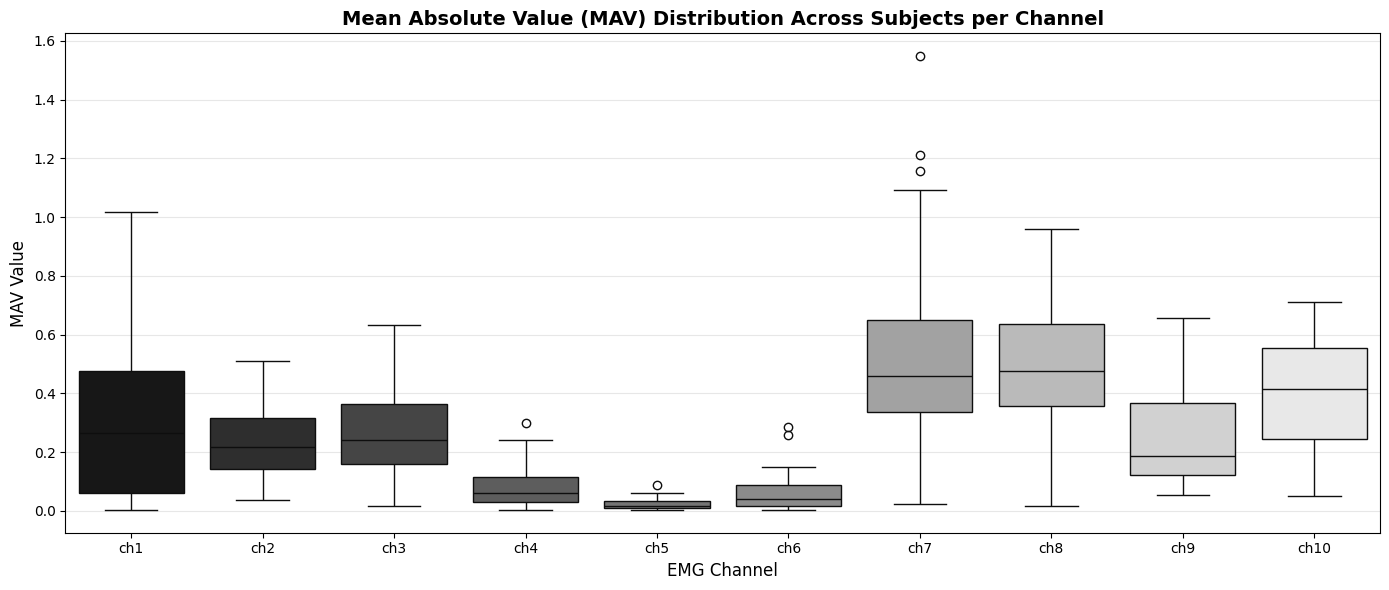

MAV Statistics per Channel:
ch1: Mean=0.3200, Std=0.3006, Min=0.0027, Max=1.0173
ch2: Mean=0.2399, Std=0.1237, Min=0.0368, Max=0.5083
ch3: Mean=0.2592, Std=0.1490, Min=0.0153, Max=0.6339
ch4: Mean=0.0838, Std=0.0717, Min=0.0031, Max=0.2989
ch5: Mean=0.0241, Std=0.0207, Min=0.0037, Max=0.0887
ch6: Mean=0.0658, Std=0.0714, Min=0.0037, Max=0.2841
ch7: Mean=0.5262, Std=0.3736, Min=0.0237, Max=1.5480
ch8: Mean=0.4829, Std=0.2327, Min=0.0156, Max=0.9578
ch9: Mean=0.2548, Std=0.1780, Min=0.0530, Max=0.6563
ch10: Mean=0.3972, Std=0.1956, Min=0.0521, Max=0.7114


In [83]:
# Boxplot for MAV features per channel across subjects

# Extract MAV features for all channels
mav_columns = [col for col in feature_df.columns if col.startswith('mav_')]
mav_data = feature_df[mav_columns]

# Rename columns for better readability (remove 'mav_' prefix)
mav_data.columns = [col.replace('mav_', '') for col in mav_data.columns]

# Melt the dataframe for seaborn boxplot
mav_melted = mav_data.reset_index().melt(
    id_vars='index',
    var_name='Channel',
    value_name='MAV Value'
)
mav_melted.rename(columns={'index': 'Subject'}, inplace=True)

# Create boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=mav_melted,
    x='Channel',
    y='MAV Value',
    palette='gray'
)
plt.title('Mean Absolute Value (MAV) Distribution Across Subjects per Channel', 
          fontsize=14, fontweight='bold')
plt.xlabel('EMG Channel', fontsize=12)
plt.ylabel('MAV Value', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary statistics per channel
print("MAV Statistics per Channel:")
print("=" * 70)
for col in mav_data.columns:
    values = mav_data[col]
    print(f"{col}: Mean={values.mean():.4f}, Std={values.std():.4f}, "
          f"Min={values.min():.4f}, Max={values.max():.4f}")


In [84]:
# ==================================================
# Within- vs Cross-Subject Comparison
# Uses precomputed `subject_features` from above cells
# ==================================================

# --------------------------
# A) Train/test within subject
# --------------------------

X_prime = subject_features[SUBJECT_OF_INTEREST]['X']
y_prime = subject_features[SUBJECT_OF_INTEREST]['y']
print(f"S{SUBJECT_OF_INTEREST}: X shape = {X_prime.shape}, classes = {len(np.unique(y_prime))}")

try:
    X_prime_train, X_prime_test, y_prime_train, y_prime_test = train_test_split(
        X_prime,
        y_prime,
        test_size=0.2,
        random_state=42,
        stratify=y_prime,
    )
except ValueError as e:
    print(f"[warn] Stratified split failed for S{SUBJECT_OF_INTEREST} ({e}); using non-stratified split.")
    X_prime_train, X_prime_test, y_prime_train, y_prime_test = train_test_split(
        X_prime,
        y_prime,
        test_size=0.2,
        random_state=42,
        stratify=None,
    )

scaler_within = StandardScaler()
X_prime_train_z = scaler_within.fit_transform(X_prime_train)
X_prime_test_z  = scaler_within.transform(X_prime_test)

clf_within = GradientBoostingClassifier(random_state=42)
clf_within.fit(X_prime_train_z, y_prime_train)
y_prime_pred = clf_within.predict(X_prime_test_z)
acc_within_prime = accuracy_score(y_prime_test, y_prime_pred)
cm_within_prime = confusion_matrix(y_prime_test, y_prime_pred)

# -----------------------------------------
# B) Train then test cross-subject
# -----------------------------------------
training_subjects = [int(s) for s in subjects if int(s) != SUBJECT_OF_INTEREST]
X_train_parts, y_train_parts = [], []
for subj in training_subjects:
    X_train_parts.append(subject_features[subj]['X'])
    y_train_parts.append(subject_features[subj]['y'])

X_unprime = np.vstack(X_train_parts)
y_unprime = np.hstack(y_train_parts)

scaler_cross = StandardScaler()
X_unprime_z = scaler_cross.fit_transform(X_unprime)
X_prime_z   = scaler_cross.transform(X_prime)

clf_cross = GradientBoostingClassifier(random_state=42)
clf_cross.fit(X_unprime_z, y_unprime)
y_prime_pred_cross = clf_cross.predict(X_prime_z)
acc_unprime_to_prime = accuracy_score(y_prime, y_prime_pred_cross)
cm_unprime_to_prime = confusion_matrix(y_prime, y_prime_pred_cross)

# --------------------------
# Comparison summary
# --------------------------
summary = pd.DataFrame([
    {
        "setting": f"Train S{SUBJECT_OF_INTEREST} / Test S{SUBJECT_OF_INTEREST} (holdout)",
        "train_samples": int(X_prime_train.shape[0]),
        "test_samples": int(X_prime_test.shape[0]),
        "accuracy": float(acc_within_prime),
    },
    {
        "setting": f"Train not S{SUBJECT_OF_INTEREST} / Test S{SUBJECT_OF_INTEREST} (all)",
        "train_samples": int(X_unprime.shape[0]),
        "test_samples": int(X_prime.shape[0]),
        "accuracy": float(acc_unprime_to_prime),
    },
]).sort_values("accuracy", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print(f"S{SUBJECT_OF_INTEREST} Generalization Comparison")
print("=" * 80)
print(summary.to_string(index=False))



S27: X shape = (120, 100), classes = 12

S27 Generalization Comparison
                       setting  train_samples  test_samples  accuracy
Train S27 / Test S27 (holdout)             96            24  0.750000
Train not S27 / Test S27 (all)           3120           120  0.208333


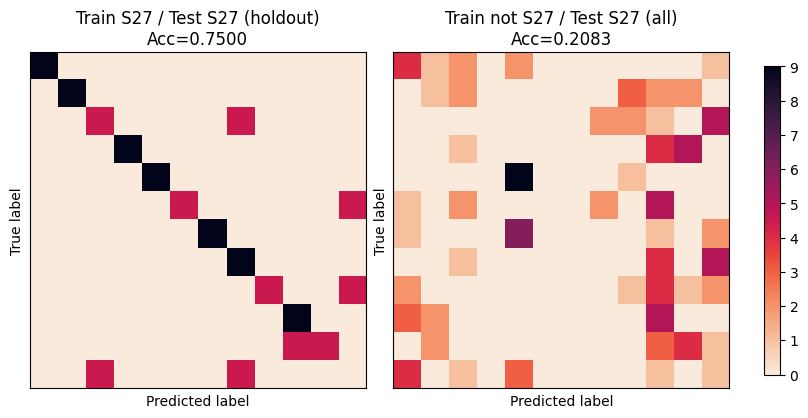

In [95]:
from matplotlib import colors

def _plot_confusion_matrix(ax, cm: np.ndarray, title: str):


    im = ax.imshow(cm, cmap="rocket_r", interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([])
    ax.set_yticks([])
    return im


# --------------------------
# Confusion matrices (plots)
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

im0 = _plot_confusion_matrix(
    axes[0],
    cm_within_prime,
    f"Train S{SUBJECT_OF_INTEREST} / Test S{SUBJECT_OF_INTEREST} (holdout)\nAcc={acc_within_prime:.4f}",
)
im1 = _plot_confusion_matrix(
    axes[1],
    cm_unprime_to_prime,
    f"Train not S{SUBJECT_OF_INTEREST} / Test S{SUBJECT_OF_INTEREST} (all)\nAcc={acc_unprime_to_prime:.4f}",
)

fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
plt.show()

In [96]:
# Leave-one-subject-out cross-validation (train on all subjects except one, test on the held-out subject)
t0 = time.time()
subject_accuracies: dict[int, float] = {}

for test_sub in subjects:
    X_train_parts, y_train_parts = [], []
    X_test, y_test = None, None

    for subj in subjects:
        X_sub = subject_features[int(subj)]["X"]
        y_sub = subject_features[int(subj)]["y"]

        if subj == test_sub:
            X_test, y_test = X_sub, y_sub
        else:
            X_train_parts.append(X_sub)
            y_train_parts.append(y_sub)

    X_train = np.vstack(X_train_parts)
    y_train = np.hstack(y_train_parts)

    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)

    clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
    clf.fit(X_train_z, y_train)

    y_pred = clf.predict(X_test_z)
    acc = accuracy_score(y_test, y_pred)
    subject_accuracies[int(test_sub)] = float(acc)

    elapsed = time.time() - t0
    print(f"t={elapsed:6.1f}s | Test subject {int(test_sub):2d} accuracy: {acc:.4f}")

accuracies = np.array(list(subject_accuracies.values()))
print(f"\nMean leave-one-subject-out accuracy: {accuracies.mean():.4f}")

t=  91.7s | Test subject  1 accuracy: 0.3750
t= 183.6s | Test subject  2 accuracy: 0.1583
t= 277.3s | Test subject  3 accuracy: 0.4250
t= 369.2s | Test subject  4 accuracy: 0.3500
t= 460.9s | Test subject  5 accuracy: 0.5000
t= 552.3s | Test subject  6 accuracy: 0.2750
t= 645.5s | Test subject  7 accuracy: 0.3917
t= 738.3s | Test subject  8 accuracy: 0.3833
t= 829.9s | Test subject  9 accuracy: 0.2833
t= 925.1s | Test subject 10 accuracy: 0.3500
t=1017.6s | Test subject 11 accuracy: 0.3250
t=1124.0s | Test subject 12 accuracy: 0.3750
t=1357.7s | Test subject 13 accuracy: 0.3667
t=1450.4s | Test subject 14 accuracy: 0.3083
t=1542.2s | Test subject 15 accuracy: 0.4167
t=1634.2s | Test subject 16 accuracy: 0.3917
t=1726.1s | Test subject 17 accuracy: 0.4667
t=1819.5s | Test subject 18 accuracy: 0.3500
t=1914.2s | Test subject 19 accuracy: 0.2417
t=2007.2s | Test subject 20 accuracy: 0.2333
t=2100.1s | Test subject 21 accuracy: 0.4667
t=2191.7s | Test subject 22 accuracy: 0.2750
t=2284.1s 

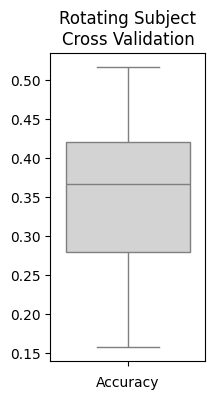

In [43]:
# Plot boxplot of accuracies across subjects
plt.figure(figsize=(2, 4))
sns.boxplot(data=accuracies, 
            orient='v',
            color="lightgrey",
            )
plt.title("Rotating Subject\nCross Validation")
plt.xlabel("Accuracy")
plt.show()

In [56]:
# Analyze impact of training set size on classification performance (single test subject)
def training_size_curve(test_subject: int, max_train_subjects: int | None = None) -> pd.DataFrame:
    """
    Returns a DataFrame with columns: n_train, accuracy, test_subject.
    max_train_subjects can be used to make the experiment fast during development.
    """
    training_subjects = [int(s) for s in subjects if int(s) != int(test_subject)]
    if max_train_subjects is not None:
        training_subjects = training_subjects[:max_train_subjects]

    X_test = subject_features[int(test_subject)]["X"]
    y_test = subject_features[int(test_subject)]["y"]

    rows = []
    for n_train in range(1, max(SUBJECT_IDS)):
        train_subs = training_subjects[:n_train]
        X_train = np.vstack([subject_features[sub]["X"] for sub in train_subs])
        y_train = np.hstack([subject_features[sub]["y"] for sub in train_subs])

        scaler = StandardScaler()
        X_train_z = scaler.fit_transform(X_train)
        X_test_z = scaler.transform(X_test)

        clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
        clf.fit(X_train_z, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test_z))

        rows.append({"n_train": n_train, "accuracy": float(acc), "test_subject": int(test_subject)})
        print(f"Train subs: {n_train:2d} | Test S{test_subject}: acc={acc:.4f}")

    return pd.DataFrame(rows)

# Keep this fast by default; set max_train_subjects=None for full curve
results_df = training_size_curve(SUBJECT_OF_INTEREST, max_train_subjects=max(SUBJECT_IDS))
print(f"\nMax acc: {results_df['accuracy'].max():.4f} at n_train={int(results_df.loc[results_df['accuracy'].idxmax(),'n_train'])}")

Train subs:  1 | Test S2: acc=0.1000
Train subs:  2 | Test S2: acc=0.1500
Train subs:  3 | Test S2: acc=0.0833
Train subs:  4 | Test S2: acc=0.1000
Train subs:  5 | Test S2: acc=0.0667
Train subs:  6 | Test S2: acc=0.0750
Train subs:  7 | Test S2: acc=0.0667
Train subs:  8 | Test S2: acc=0.1167
Train subs:  9 | Test S2: acc=0.0750
Train subs: 10 | Test S2: acc=0.0750
Train subs: 11 | Test S2: acc=0.0583
Train subs: 12 | Test S2: acc=0.0750
Train subs: 13 | Test S2: acc=0.0583
Train subs: 14 | Test S2: acc=0.0833
Train subs: 15 | Test S2: acc=0.0417
Train subs: 16 | Test S2: acc=0.0833
Train subs: 17 | Test S2: acc=0.1083
Train subs: 18 | Test S2: acc=0.1000
Train subs: 19 | Test S2: acc=0.0917
Train subs: 20 | Test S2: acc=0.0917
Train subs: 21 | Test S2: acc=0.0500
Train subs: 22 | Test S2: acc=0.0917
Train subs: 23 | Test S2: acc=0.0833
Train subs: 24 | Test S2: acc=0.0833
Train subs: 25 | Test S2: acc=0.1167
Train subs: 26 | Test S2: acc=0.1583

Max acc: 0.1583 at n_train=26


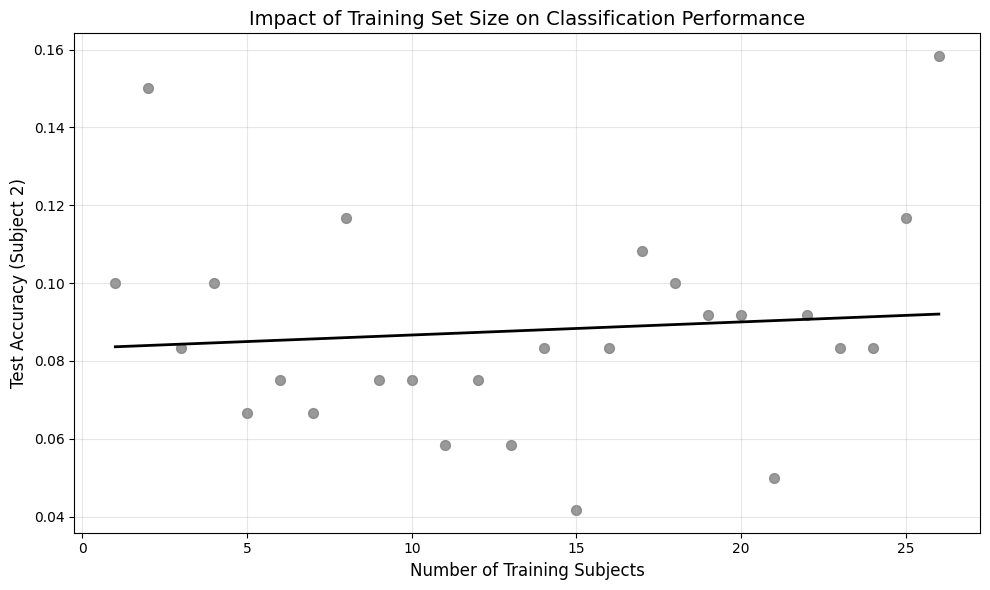

In [57]:
# Plot the training-size curve for the current `results_df`
plt.figure(figsize=(10, 6))
sns.regplot(
    data=results_df,
    x="n_train",
    y="accuracy",
    marker="o",
    color="gray",
    scatter_kws={"s": 50},
    line_kws={"color": "black", "linewidth": 2},
    ci=None,
 )
plt.xlabel("Number of Training Subjects", fontsize=12)
plt.ylabel(f"Test Accuracy (Subject {SUBJECT_OF_INTEREST})", fontsize=12)
plt.title("Impact of Training Set Size on Classification Performance", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
# (Optional) Training-size experiment across multiple test subjects
def training_size_experiment(
    test_subjects: list[int],
    *,
    max_train_subjects: int | None = 10,
    ) -> pd.DataFrame:
    """Run training-size curves for each test subject.
    This can take a long time if max_train_subjects=None (full 26-step curve)."""

    all_rows = []
    for test_subject in test_subjects:
        print(f"\n=== Testing on subject {test_subject} ===")
        df_sub = training_size_curve(test_subject, max_train_subjects=max_train_subjects)
        all_rows.append(df_sub)
    return pd.concat(all_rows, ignore_index=True)

# every 3 subjects, including subject of interest
test_subjects = [s for s in SUBJECT_IDS if s % 3 == (SUBJECT_OF_INTEREST % 3)]
print(test_subjects)

# results_df_multi = training_size_experiment(test_subjects, max_train_subjects=max(SUBJECT_IDS))

[2, 5, 8, 11, 14, 17, 20, 23, 26]


In [59]:
# Save training-size results (optional)
output_path = "results/training_size_vs_accuracy.csv"
results_df_multi.to_csv(output_path, index=False)
print(f"Saved: {output_path} ({len(results_df_multi)} rows)")

Saved: results/training_size_vs_accuracy.csv (234 rows)


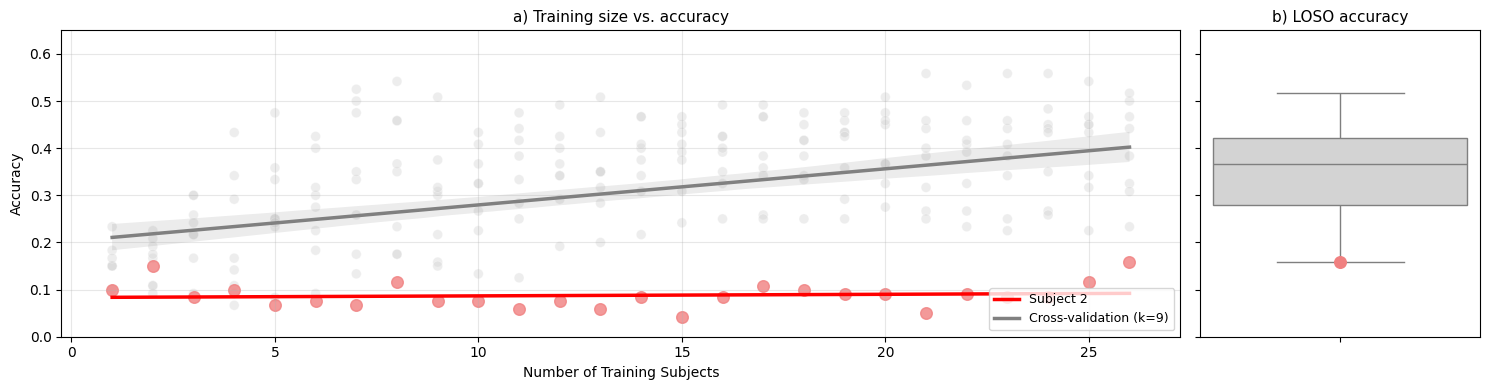

In [61]:
# Combined figure: training-size scatter + LOSO accuracy boxplot
results_df_plot = pd.read_csv("results/training_size_vs_accuracy.csv")

subject_of_interest = SUBJECT_OF_INTEREST
other_df = results_df_plot[results_df_plot["test_subject"] != subject_of_interest]
subject_df = results_df_plot[results_df_plot["test_subject"] == subject_of_interest]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4), gridspec_kw={"width_ratios": [4, 1]})

# (a) Training size vs. accuracy
sns.scatterplot(
    data=other_df,
    x="n_train",
    y="accuracy",
    hue="test_subject",
    palette=["lightgrey"] * other_df["test_subject"].nunique(),
    legend=False,
    alpha=0.4,
    s=50,
    ax=axes[0],
 )

sns.regplot(
    data=subject_df,
    x="n_train",
    y="accuracy",
    scatter_kws={"s": 70, "color": "lightcoral", "alpha": 0.8},
    line_kws={"color": "red", "linewidth": 2.5},
    ci=None,
    ax=axes[0],
 )

sns.regplot(
    data=results_df_plot,
    x="n_train",
    y="accuracy",
    scatter=False,
    color="gray",
    line_kws={"linewidth": 2.5},
    ax=axes[0],
 )

legend_elements = [
    Line2D([], [], color="red", linewidth=2.5, label=f"Subject {subject_of_interest}"),
    Line2D([], [], color="gray", linewidth=2.5, label=f"Cross-validation (k={len(test_subjects)})"),
 ]
axes[0].legend(handles=legend_elements, loc="lower right", fontsize=9)
axes[0].set_title("a) Training size vs. accuracy", fontsize=11)
axes[0].set_xlabel("Number of Training Subjects")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.00, 0.65)
axes[0].grid(True, alpha=0.3)

# (b) Boxplot of LOSO accuracies (computed earlier)
sns.boxplot(data=accuracies, orient="v", color="lightgrey", ax=axes[1])
axes[1].set_title("b) LOSO accuracy", fontsize=11)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_yticklabels([])
axes[1].set_ylim(0.00, 0.65)

# Highlight subject of interest, if it exists in the LOSO run
if 1 <= subject_of_interest <= len(accuracies):
    axes[1].scatter(
        x=[0],
        y=[accuracies[subject_of_interest - 1]],
        color="lightcoral",
        marker="o",
        s=70,
        zorder=100,
    )

plt.tight_layout()
plt.show()